# 법인 DX 전환 예측 — 데이터 전처리 파이프라인

**출력 파일**
- `outputs/processed/dx_processed.csv` — 파생변수 포함 전처리 완료
- `outputs/processed/modeling_columns.json` — 모델 피처 목록
- `outputs/processed/customer_type_stats.csv` — 고객 유형별 법인 수

In [10]:
import os, re, json, warnings
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)

## 0. 설정

In [ ]:
# ── 데이터 경로 (여기만 수정) ──────────────────────────────────────────────
DATA_PATH   = "/Users/gggyyu/Desktop/(아이엠뱅크) 2026 교육용 데이터/(iM뱅크) 2026 교육용 법인 익명데이터.xlsx"   # xlsx 또는 csv
cwd = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(cwd, '..', '..')) if os.path.basename(cwd) == 'preprocessing' else (os.path.abspath(os.path.join(cwd, '..')) if os.path.basename(cwd) == 'src' else cwd)
OUTPUT_DIR  = os.path.join(PROJECT_ROOT, 'outputs', 'processed')
SPLIT_CUTOFF = '2025-01-01'           # train/test 분할 기준일

# ── 간헐적 고객 처리 방식 ─────────────────────────────────────────────────
# True  → 내부 공백 있는 법인 제거 (모델링 노트북과 동일 방식)
# False → 전체 보존 + '고객유형' 컬럼으로 태그만 부여 (EDA 등에 활용)
FILTER_CONTINUOUS_ONLY = False
# ─────────────────────────────────────────────────────────────────────────────

GLOBAL_FIRST_MONTH = '2023-01'
GLOBAL_LAST_MONTH  = '2025-12'
TOTAL_MONTHS       = 36

GRADE_MAP = {'최우수': 2, '우수': 1, '일반': 0}

ALWAYS_EXCLUDE = {
    '기준년월', '법인ID', '기준년월_dt',
    'expected_next_month', 'next_month', 'split',
    'next_online_share', 'next_online_amount', 'next_online_share_delta',
    'target_online_share_up_5pp', 'target_new_online_activation',
    'Y_t1', 'Y_t3',
    '법인_고객등급', '전담고객여부',
    '업종_대분류', '업종_중분류', '사업장_시도', '사업장_시군구',
    'month', '_월순서', '_월diff',
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('설정 완료')

설정 완료


## 1. 데이터 로드

In [14]:
ext = os.path.splitext(DATA_PATH)[-1].lower()
if ext in ('.xlsx', '.xls'):
    df_raw = pd.read_excel(DATA_PATH)
else:
    df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

print(f'원본 shape: {df_raw.shape}')
df_raw.head(3)

원본 shape: (365988, 70)


,기준년월,법인ID,업종_대분류,업종_중분류,사업장_시도,사업장_시군구,법인_고객등급,전담고객여부,요구불예금잔액,거치식예금잔액,...,시설_기타시설자금대출좌수,신용카드개수,외환_수출실적거래건수,외환_수입실적거래건수,창구거래건수,인터넷뱅킹거래건수,스마트뱅킹거래건수,폰뱅킹거래건수,ATM거래건수,자동이체거래건수
0,202301,c665c79135345c7be173ebcc61465fe0bde03d935a1ce5...,제조업,섬유제품 제조업; 의복제외,대구,대구광역시,최우수,Y,9.20,0.00,...,1개,10개초과 20개이하,0건,0건,40건초과 50건이하,50건 초과,0건,0건,2건초과 5건이하,40건초과 50건이하
1,202301,f23f02d337472145be9201d56547d33721c76ec63c5efd...,부동산업,부동산업,대구,대구광역시,일반,N,0.11,0.00,...,0개,2개,0건,0건,0건,5건초과 10건이하,1건,0건,0건,10건초과 20건이하
2,202301,4da4658f20a49e7ca3872154f20cf20631aa1d7cf6b0d4...,도매 및 소매업,도매 및 상품 중개업,대구,대구광역시,우수,Y,38.00,0.00,...,0개,2개,0건,0건,20건초과 30건이하,40건초과 50건이하,2건초과 5건이하,1건,1건,5건초과 10건이하


## 2. 데이터 타입 변환

In [15]:
def parse_count(s) -> float:
    """범주형 건수 문자열 → 수치 중간값. 예) '2초과~5이하' → 3.5"""
    if pd.isna(s): return 0.0
    s = str(s).replace(',', '').strip()
    nums = re.findall(r'\d+', s)
    if not nums: return 0.0
    if '초과' in s and '이하' in s: return (int(nums[0]) + int(nums[1])) / 2.0
    if '초과' in s: return float(nums[0]) + 1.0
    return float(nums[0])

In [16]:
df = df_raw.copy()

# 기준년월 → datetime
ym = df['기준년월'].astype(str).str.strip()
if ym.str.match(r'^\d{6}$').all():
    df['기준년월'] = pd.to_datetime(ym, format='%Y%m')
else:
    df['기준년월'] = pd.to_datetime(ym.str[:7], format='%Y-%m')

# 건수/개수/좌수 → float
count_cols = [c for c in df.columns if any(k in c for k in ['건수', '개수', '좌수'])]
for c in count_cols:
    if df[c].dtype == object:
        df[c] = df[c].apply(parse_count)
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0.0)

# 금액/잔액/한도 → float
money_cols = [c for c in df.columns if any(k in c for k in ['금액', '잔액', '한도'])]
for c in money_cols:
    if df[c].dtype == object:
        df[c] = df[c].astype(str).str.replace(',', '', regex=False).str.strip()
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0.0)

df = df.sort_values(['법인ID', '기준년월']).reset_index(drop=True)
print(f'타입 변환 완료: {df.shape}')
df.dtypes.value_counts()

타입 변환 완료: (365988, 70)


float64           60
object             7
int64              2
datetime64[ns]     1
Name: count, dtype: int64

## 3. 범주형 인코딩

In [17]:
# 법인_고객등급 → ordinal
if '법인_고객등급' in df.columns:
    df['법인_고객등급_enc'] = df['법인_고객등급'].map(GRADE_MAP).fillna(0).astype(int)

# 전담고객여부 → binary
if '전담고객여부' in df.columns:
    df['전담고객여부_enc'] = (df['전담고객여부'].astype(str).str.upper() == 'Y').astype(int)

# 업종/지역 → LabelEncoder
le_targets = [c for c in ['업종_대분류', '업종_중분류', '사업장_시도', '사업장_시군구'] if c in df.columns]
for c in le_targets:
    le = LabelEncoder()
    df[c + '_enc'] = le.fit_transform(df[c].astype(str).fillna('unknown'))

print('범주형 인코딩 완료')
enc_cols = [c for c in df.columns if c.endswith('_enc')]
df[enc_cols].head(3)

범주형 인코딩 완료


,법인_고객등급_enc,전담고객여부_enc,업종_대분류_enc,업종_중분류_enc,사업장_시도_enc,사업장_시군구_enc
0,2,1,10,29,1,4
1,2,1,10,29,1,4
2,2,1,10,29,1,4


## 4. 고객 유형 분류

| 유형 | 조건 |
|------|------|
| 장기 | 36개월 전체 연속 등장 |
| 신규 | 중간부터 등장 → 끝까지 (내부·후행 공백 없음) |
| 이탈 | 처음부터 등장 → 중간에 이탈 (내부 공백 없음) |
| 간헐적 | 내부 공백 존재 |

In [18]:
global_first = df['기준년월'].min()
global_last  = df['기준년월'].max()
all_corps_n  = df['법인ID'].nunique()

# 내부 공백 탐지 — 모델링 노트북과 동일한 방식
df = df.sort_values(['법인ID', '기준년월']).reset_index(drop=True)
df['_월순서'] = df['기준년월'].dt.year * 12 + df['기준년월'].dt.month
df['_월diff'] = df.groupby('법인ID')['_월순서'].diff()

gap_corps        = set(df.loc[df['_월diff'] > 1, '법인ID'].unique())
continuous_corps = [c for c in df['법인ID'].unique() if c not in gap_corps]

df = df.drop(columns=['_월순서', '_월diff'])

print(f'전체 법인: {all_corps_n:,}  |  간헐적(내부 공백): {len(gap_corps):,}  |  연속: {len(continuous_corps):,}')

# ── 연속 법인 내 세부 유형 분류 ──────────────────────────────────────────
grp = df.groupby('법인ID')['기준년월']
corp_first = grp.min()
corp_last  = grp.max()
corp_count = grp.count()

starts_first = set(corp_first[corp_first == global_first].index)
ends_last    = set(corp_last[corp_last   == global_last].index)

def get_type(cid):
    if cid in gap_corps:
        return '간헐적'
    s = cid in starts_first
    e = cid in ends_last
    if s and e and corp_count[cid] == TOTAL_MONTHS:
        return '장기'
    if not s and e:
        return '신규'
    if s and not e:
        return '이탈'
    return '기타'

type_map = pd.Series({cid: get_type(cid) for cid in df['법인ID'].unique()}, name='고객유형')
df = df.merge(type_map.reset_index().rename(columns={'index': '법인ID'}), on='법인ID', how='left')

# ── FILTER_CONTINUOUS_ONLY 옵션 적용 ─────────────────────────────────────
if FILTER_CONTINUOUS_ONLY:
    before = len(df)
    df = (
        df[df['법인ID'].isin(continuous_corps)]
        .reset_index(drop=True)
    )
    print(f'[간헐적 제거] {before:,}행 → {len(df):,}행  ({before - len(df):,}행 제거)')

stats = df.groupby('고객유형')['법인ID'].nunique().rename('법인수')
print('\n[고객 유형 분포]')
display(stats.to_frame())

전체 법인: 15,473  |  간헐적(내부 공백): 6,416  |  연속: 9,057

[고객 유형 분포]


,법인수
고객유형,
간헐적,6416
기타,573
신규,2643
이탈,2469
장기,3372


## 5. 파생변수 생성 (92개)

| 그룹 | 범위 | 내용 |
|------|------|------|
| A | 1~17 | 오프라인 채널 구조 (금액·건수·점유율·flag) |
| B | 18~27 | 자동화 성향 (카드·외환·온라인이용여부) |
| C | 28~40 | 재무 비율 + log1p 변환 |
| D | 41~57 | 3·6개월 롤링 통계 |
| E | 58~64 | Lag · 변화율 |
| F | 65~72 | 상호작용 피처 |
| G | 73~92 | 온라인건수 계열 lag/rolling · 월 계절성 · 지수 |

In [19]:
def _col(df, name, default=0.0):
    return df[name] if name in df.columns else pd.Series(default, index=df.index)

def _safe_div(num, den, fill=0.0):
    return pd.Series(np.where(den.values == 0, fill, num.values / den.values), index=num.index)

def _lag(df, col, n):
    return df.groupby('법인ID')[col].shift(n)

def _roll(df, col, window, func='mean'):
    lagged = _lag(df, col, 1)
    grp = lagged.groupby(df['법인ID'])
    if func == 'mean':
        return grp.transform(lambda s: s.rolling(window, min_periods=1).mean())
    if func == 'std':
        return grp.transform(lambda s: s.rolling(window, min_periods=2).std())

print('헬퍼 함수 정의 완료')

헬퍼 함수 정의 완료


In [26]:
# ── 원본 채널 컬럼 ─────────────────────────────────────────────────────
internet_amt = _col(df, '인터넷뱅킹거래금액')
smart_amt    = _col(df, '스마트뱅킹거래금액')
branch_amt   = _col(df, '창구거래금액')
atm_amt      = _col(df, 'ATM거래금액')
phone_amt    = _col(df, '폰뱅킹거래금액')
internet_cnt = _col(df, '인터넷뱅킹거래건수')
smart_cnt    = _col(df, '스마트뱅킹거래건수')
branch_cnt   = _col(df, '창구거래건수')
atm_cnt      = _col(df, 'ATM거래건수')
phone_cnt    = _col(df, '폰뱅킹거래건수')
_auto = '자동이체금액' if '자동이체금액' in df.columns else '자동이체거래금액' if '자동이체거래금액' in df.columns else None
auto_amt = _col(df, _auto) if _auto else pd.Series(0.0, index=df.index)

# ── 그룹 A: 채널 구조 (var 1~17) ──────────────────────────────────────
df['online_amount']        = internet_amt + smart_amt
df['offline_amount']       = branch_amt + atm_amt + phone_amt
df['total_channel_amount'] = df['online_amount'] + df['offline_amount']

df['online_count']        = internet_cnt + smart_cnt
df['offline_count']       = branch_cnt + atm_cnt + phone_cnt
df['total_channel_count'] = df['online_count'] + df['offline_count']

total_a = df['total_channel_amount']
df['online_share']              = _safe_div(df['online_amount'], total_a)
df['branch_share']              = _safe_div(branch_amt,          total_a)
df['atm_share']                 = _safe_div(atm_amt,             total_a)
df['phone_share']               = _safe_div(phone_amt,           total_a)
df['internet_share_in_online']  = _safe_div(internet_amt,        df['online_amount'])
df['smart_share_in_online']     = _safe_div(smart_amt,           df['online_amount'])

total_c = df['total_channel_count']
df['online_count_share'] = _safe_div(df['online_count'], total_c)
df['branch_count_share'] = _safe_div(branch_cnt,         total_c)

df['is_no_channel']    = (df['total_channel_amount'] <= 0).astype(int)
df['is_online_active'] = (df['online_amount'] > 0).astype(int)
df['is_smart_active']  = (smart_amt > 0).astype(int)

# ── 그룹 B: 자동화 성향 (var 18~27) ───────────────────────────────────
df['is_internet_active']   = (internet_amt > 0).astype(int)
df['is_branch_active']     = (branch_amt > 0).astype(int)
df['is_atm_active']        = (atm_amt > 0).astype(int)
df['is_auto_transfer']     = (auto_amt > 0).astype(int)

credit_amt = _col(df, '신용카드사용금액')
check_amt  = _col(df, '체크카드사용금액')
df['card_total']   = credit_amt + check_amt
df['credit_share'] = _safe_div(credit_amt, df['card_total'])
df['check_share']  = _safe_div(check_amt,  df['card_total'])

export_amt = _col(df, '외환_수출실적금액')
import_amt = _col(df, '외환_수입실적금액')
df['fx_total']     = export_amt + import_amt
df['is_fx_active'] = (df['fx_total'] > 0).astype(int)

df['온라인이용여부'] = (
    (_col(df, '인터넷뱅킹거래건수') > 0) | (_col(df, '스마트뱅킹거래건수') > 0)
).astype(int)

print('그룹 A·B 완료')

그룹 A·B 완료


In [27]:
# ── 그룹 C: 재무 비율 + log1p (var 28~40) ──────────────────────────────
deposit     = _col(df, '수신잔액')
loan_bal    = _col(df, '여신잔액')
loan_limit  = _col(df, '여신한도금액')
operating   = _col(df, '운전자금대출잔액')
facility    = _col(df, '시설자금대출잔액')
dep_in      = _col(df, '요구불입금금액')
dep_out     = _col(df, '요구불출금금액')

# 여신잔액이 원본에 없을 때 그룹 G에서 참조할 수 있도록 df 컬럼으로 저장
df['loan_total'] = loan_bal

df['loan_util_rate']       = _safe_div(loan_bal, loan_limit)
df['loan_deposit_ratio']   = _safe_div(loan_bal, deposit)
df['operating_loan_share'] = _safe_div(operating, loan_bal)
df['facility_loan_share']  = _safe_div(facility,  loan_bal)
df['net_cashflow']         = dep_in - dep_out
df['cashflow_ratio']       = _safe_div(df['net_cashflow'], dep_in + dep_out)

for src, dst in [
    ('online_amount',        'log1p_online_amount'),
    ('offline_amount',       'log1p_offline_amount'),
    ('total_channel_amount', 'log1p_total_channel'),
    ('card_total',           'log1p_card'),
    ('fx_total',             'log1p_fx'),
    ('수신잔액',               'log1p_deposit'),
    ('여신잔액',               'log1p_loan'),
]:
    df[dst] = np.log1p(_col(df, src).clip(lower=0))

print('그룹 C 완료')

그룹 C 완료


In [28]:
# ── 그룹 D: 3·6개월 롤링 (var 41~57) ──────────────────────────────────
for src, dst in [
    ('online_amount',  'online_roll3_mean'),
    ('offline_amount', 'offline_roll3_mean'),
    ('online_count',   'online_cnt_roll3'),
    ('온라인이용여부',    'online_use_roll3'),
    ('수신잔액',         'deposit_roll3'),
]:
    if src in df.columns:
        df[dst] = _roll(df, src, 3, 'mean')

for src, dst in [
    ('online_amount',  'online_roll6_mean'),
    ('offline_amount', 'offline_roll6_mean'),
    ('수신잔액',         'deposit_roll6'),
]:
    if src in df.columns:
        df[dst] = _roll(df, src, 6, 'mean')

df['active_months_3'] = (
    df.groupby('법인ID')['온라인이용여부']
    .apply(lambda s: s.shift(1).rolling(3, min_periods=1).sum())
    .reset_index(level=0, drop=True)
)
df['active_months_6'] = (
    df.groupby('법인ID')['온라인이용여부']
    .apply(lambda s: s.shift(1).rolling(6, min_periods=1).sum())
    .reset_index(level=0, drop=True)
)

print('그룹 D 완료')

그룹 D 완료


In [29]:
# ── 그룹 E: Lag·변화율 (var 58~64) ────────────────────────────────────
df['online_share_lag1']      = _lag(df, 'online_share', 1)
df['online_share_diff1']     = df['online_share'] - df['online_share_lag1']
df['online_amount_lag1']     = _lag(df, 'online_amount', 1)
df['online_amount_growth1']  = _safe_div(
    df['online_amount'] - df['online_amount_lag1'],
    df['online_amount_lag1'].fillna(0),
)
df['offline_amount_lag1']     = _lag(df, 'offline_amount', 1)
df['prev_month_zero_online']  = (df['online_amount_lag1'] == 0).astype(int)
df['prev_month_zero_offline'] = (df['offline_amount_lag1'] == 0).astype(int)

# ── 그룹 F: 상호작용 (var 65~72) ──────────────────────────────────────
grade_enc = df['법인_고객등급_enc'] if '법인_고객등급_enc' in df.columns else 0
dedic_enc = df['전담고객여부_enc']   if '전담고객여부_enc'  in df.columns else 0

df['전담_등급_interact']      = dedic_enc * grade_enc
df['online_x_grade']          = df['online_share'] * grade_enc
df['card_x_online']           = df['card_total']   * df['is_online_active']
df['fx_x_online']             = df['fx_total']     * df['is_online_active']
df['deposit_x_online_share']  = _col(df, '수신잔액') * df['online_share']
df['active_ratio_6m']         = _safe_div(
    df['active_months_6'],
    pd.Series(6.0, index=df.index),
)
df['online_diversity']        = (internet_amt > 0).astype(int) + (smart_amt > 0).astype(int)
df['online_share_lag1_x_grade'] = df['online_share_lag1'].fillna(0) * grade_enc

print('그룹 E·F 완료')

그룹 E·F 완료


In [30]:
# ── 그룹 G: 온라인건수 계열 · 계절성 · 지수 (var 73~92) ───────────────

# 73: 온라인 거래건수
df['Y2_온라인거래건수'] = _col(df, '인터넷뱅킹거래건수') + _col(df, '스마트뱅킹거래건수')

# 74~76: lag 1/2/3
df['온라인거래건수_lag1'] = _lag(df, 'Y2_온라인거래건수', 1)
df['온라인거래건수_lag2'] = _lag(df, 'Y2_온라인거래건수', 2)
df['온라인거래건수_lag3'] = _lag(df, 'Y2_온라인거래건수', 3)

# 77: 최근 3개월 평균
df['온라인거래_최근3개월평균'] = _roll(df, 'Y2_온라인거래건수', 3, 'mean')

# 78: 최근 3개월 표준편차
df['온라인거래_최근3개월표준편차'] = _roll(df, 'Y2_온라인거래건수', 3, 'std')

# 79: 3개월 변화 (lag1 - lag3)
df['온라인거래_3개월변화'] = df['온라인거래건수_lag1'].fillna(0) - df['온라인거래건수_lag3'].fillna(0)

# 80~82: 채널 금액 lag1
df['디지털거래금액_lag1']  = _lag(df, 'online_amount',        1)
df['오프라인거래금액_lag1'] = _lag(df, 'offline_amount',       1)
df['전체채널거래금액_lag1'] = _lag(df, 'total_channel_amount', 1)

# 83~84: 채널 점유율 lag1
df['디지털거래비중_lag1']  = _lag(df, 'online_share', 1)
_off_lag1 = _lag(df, 'offline_amount', 1).fillna(0)
_tot_lag1 = _lag(df, 'total_channel_amount', 1).fillna(0).replace(0, np.nan)
df['오프라인거래비중_lag1'] = _safe_div(_off_lag1, _tot_lag1)

# 85~87: 여신·한도소진율·순입출금 lag1
loan_src = '여신잔액' if '여신잔액' in df.columns else 'loan_total'
df['총대출잔액_lag1']     = _lag(df, loan_src,         1)
df['대출한도소진율_lag1'] = _lag(df, 'loan_util_rate', 1)
df['순입출금_lag1']       = _lag(df, 'net_cashflow',   1)

# 88~89: 계절성
df['month']  = df['기준년월'].dt.month
df['월_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['월_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# 90: 연도
df['연도'] = df['기준년월'].dt.year

# 91: EDA 우선순위 점수 (오프라인 많고 온라인 미이용 → 전환 여지)
df['eda_priority_score'] = (
    np.log1p(df['offline_amount'].clip(lower=0))
    - np.log1p(df['online_amount'].clip(lower=0))
    + (1 - df['온라인이용여부']) * 5
)

# 92: 복합 자동화 성향 지수
df['auto_tendency_index'] = (
    df['atm_share'] + (df['card_total'] > 0).astype(int) + df['온라인이용여부']
) / 3.0

# 보조 날짜 컬럼
df['기준년월_dt']         = df['기준년월']
df['expected_next_month'] = df['기준년월'] + pd.DateOffset(months=1)
df['next_month']          = df.groupby('법인ID')['기준년월'].shift(-1)
df['months_observed']     = df.groupby('법인ID').cumcount() + 1

print(f'그룹 G 완료 | 전체 컬럼 수: {df.shape[1]}')

그룹 G 완료 | 전체 컬럼 수: 166


## 6. 타깃 변수 생성

In [31]:
df = df.sort_values(['법인ID', '기준년월']).reset_index(drop=True)

s1 = df.groupby('법인ID')['온라인이용여부'].shift(-1)
s2 = df.groupby('법인ID')['온라인이용여부'].shift(-2)
s3 = df.groupby('법인ID')['온라인이용여부'].shift(-3)

# Y_t1: t+1 온라인 이용 여부
df['Y_t1'] = s1.where(~s1.isna()).astype('Int64')

# Y_t3: t+1~t+3 중 한 번이라도 이용 (마지막 3개월 NaN)
y3_raw = ((s1 == 1) | (s2 == 1) | (s3 == 1)).astype(float)
df['Y_t3'] = y3_raw.where(~s3.isna()).astype('Int64')

# 보조 타깃
df['next_online_share']          = df.groupby('법인ID')['online_share'].shift(-1)
df['next_online_share_delta']    = df['next_online_share'] - df['online_share']
df['target_online_share_up_5pp'] = (df['next_online_share_delta'] >= 0.05).astype('Int64')
df['target_new_online_activation'] = (
    (df['온라인이용여부'] == 0) & (s1 == 1)
).astype('Int64')

# train/test split
cutoff_dt  = pd.to_datetime(SPLIT_CUTOFF)
df['split'] = np.where(df['기준년월'] < cutoff_dt, 'train', 'test')

print(f'타깃 생성 완료')
print(df[['Y_t1', 'Y_t3']].apply(lambda c: c.value_counts(dropna=False)))

타깃 생성 완료
        Y_t1    Y_t3
1     250710  253215
0      99805   67333
<NA>   15473   45440


## 7. 저장

In [32]:
# ── 처리 데이터 저장 ──────────────────────────────────────────────────
out_csv = os.path.join(OUTPUT_DIR, 'dx_processed.csv')
df.to_csv(out_csv, index=False, encoding='utf-8-sig')
print(f'저장: {out_csv}  ({df.shape[0]:,}행 × {df.shape[1]}열)')

# ── 고객 유형 통계 저장 ───────────────────────────────────────────────
stats_path = os.path.join(OUTPUT_DIR, 'customer_type_stats.csv')
df.groupby('고객유형')['법인ID'].nunique().rename('법인수').to_csv(stats_path, encoding='utf-8-sig')
print(f'고객 유형 통계: {stats_path}')

# ── 모델 피처 목록 저장 ───────────────────────────────────────────────
feat_cols = [
    c for c in df.columns
    if c not in ALWAYS_EXCLUDE
    and df[c].dtype in [np.float64, np.int64, np.int32, 'Int64', float, int]
    and df[c].notna().any()
]
meta = {
    'feature_cols': feat_cols,
    'target_t1': 'Y_t1',
    'target_t3': 'Y_t3',
    'split_col': 'split',
    'id_col': '법인ID',
    'date_col': '기준년월',
    'customer_type_col': '고객유형',
    'n_features': len(feat_cols),
}
meta_path = os.path.join(OUTPUT_DIR, 'modeling_columns.json')
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print(f'모델 피처 목록: {meta_path}  ({len(feat_cols)}개 피처)')

저장: ../outputs/processed\dx_processed.csv  (365,988행 × 173열)
고객 유형 통계: ../outputs/processed\customer_type_stats.csv
모델 피처 목록: ../outputs/processed\modeling_columns.json  (153개 피처)


## 8. 결과 확인

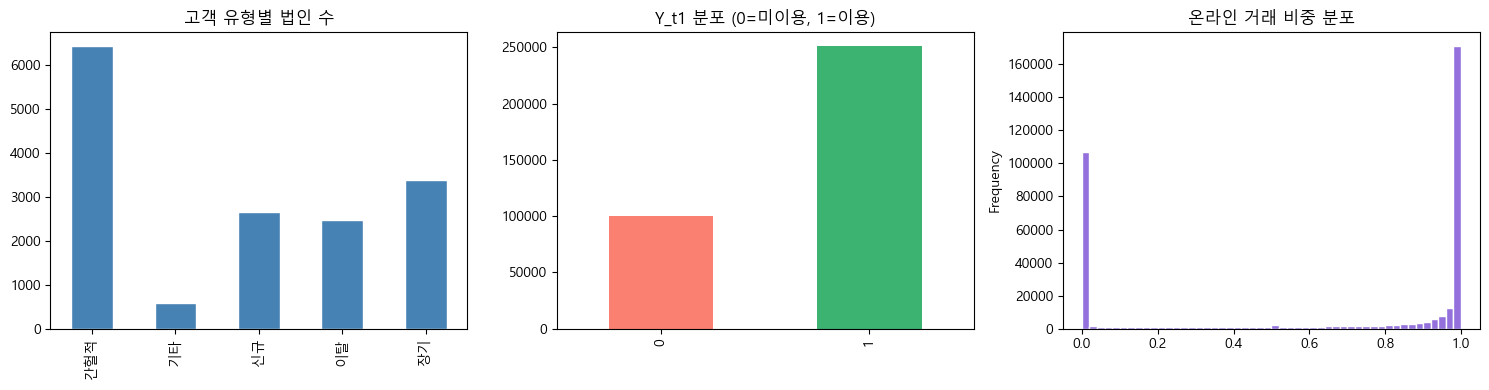


최종 shape: (365988, 173)

train: 243,220행  |  test: 122,768행


In [34]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 고객 유형 분포
df.groupby('고객유형')['법인ID'].nunique().plot.bar(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('고객 유형별 법인 수')
axes[0].set_xlabel('')

# Y_t1 분포
df['Y_t1'].value_counts(dropna=True).sort_index().plot.bar(ax=axes[1], color=['salmon', 'mediumseagreen'])
axes[1].set_title('Y_t1 분포 (0=미이용, 1=이용)')
axes[1].set_xlabel('')

# online_share 분포
df['online_share'].plot.hist(bins=50, ax=axes[2], color='mediumpurple', edgecolor='white')
axes[2].set_title('온라인 거래 비중 분포')

plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, 'preprocessing_summary.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close(fig)
print(f'전처리 요약 그래프: {fig_path}')

print(f'\n최종 shape: {df.shape}')
print(f'\ntrain: {(df["split"]=="train").sum():,}행  |  test: {(df["split"]=="test").sum():,}행')